# PGA Tour Tournament-Level Performance Data

## Overview and Problem Definition

Author: Clinton Baker

Date: 2/28/2026

This project analyzes PGA Tour tournament-level performance data.  Each row represents a player's performance in a specific tournament.  The dataset includes strokes gained statistics, scoring information, and finishing position.

The primary research questions are:

1. Which strokes gained components are most strongly associated with better finishing positions?
2. What statistical differences exist between players who finish in the top 10 and those who do not?

To answer these questions, I will perform data cleaning, exploratory analysis, correlation analysis, and comparative statistical analysis using pandas, NumPy, and matplotlib.

## Data Verification and Cleaning

### Data Source
The dataset used in this project is PGA Tour Golf Data (2015-2022)

Author: Rob Mulla

Source: Kaggle

URL: https://www.kaggle.com/datasets/robikscube/pga-tour-golf-data-20152022

The dataset contains PGA tour tournament related data.  Each row represents a player's performance in a specific tournament.  The dataset includes strokes gained statistics (putting, approach, tee shot, around the green, total), scoring data, finishing position, purse information, and season.

The dataset will be analyzed to determine which performance metrics most strongly influence finishing position and which metrics distinguish top 10 finishes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("pga_raw_data.csv")
df.head()

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


In [3]:
df.shape

(36864, 37)

In [4]:
df.isna().sum()

Player_initial_last        0
tournament id              0
player id                  0
hole_par                   0
strokes                    0
hole_DKP                   0
hole_FDP                   0
hole_SDP                   0
streak_DKP                 0
streak_FDP                 0
streak_SDP                 0
n_rounds                   0
made_cut                   0
pos                    15547
finish_DKP                 0
finish_FDP                 0
finish_SDP                 0
total_DKP                  0
total_FDP                  0
total_SDP                  0
player                     0
Unnamed: 2             36864
Unnamed: 3             36864
Unnamed: 4             36864
tournament name            0
course                     0
date                       0
purse                      0
season                     0
no_cut                     0
Finish                  7683
sg_putt                 7684
sg_arg                  7684
sg_app                  7684
sg_ott        

In [5]:
df.describe()

,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,streak_SDP,...,Unnamed: 4,purse,season,no_cut,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
count,3.686400e+04,3.686400e+04,36864.000000,36864.000000,36864.000000,36864.000000,36864.000000,36864.000000,36864.000000,36864.000000,...,0.0,36864.000000,36864.000000,36864.000000,29180.000000,29180.000000,29180.000000,29180.000000,29180.000000,29181.000000
mean,2.331807e+08,7.979041e+04,225.547065,224.114502,50.130249,44.375789,49.323703,1.764052,7.686844,1.683485,...,NaN,7.529612,2018.539686,0.065294,-0.121005,-0.040744,-0.101759,-0.045896,-0.188346,-0.305491
std,1.979221e+08,5.753816e+05,70.295590,66.789007,24.025854,24.153313,22.202915,2.846552,7.252924,2.668202,...,NaN,2.192712,2.213050,0.247047,1.119451,0.727315,1.119763,0.808139,1.640817,1.966669
min,2.230000e+03,5.000000e+00,70.000000,66.000000,-2.500000,-21.400000,-11.000000,0.000000,0.000000,0.000000,...,NaN,3.000000,2015.000000,0.000000,-5.990000,-6.430000,-9.250000,-7.740000,-13.950000,-13.670000
25%,2.696000e+03,1.170000e+03,143.000000,146.000000,27.000000,22.600000,28.000000,0.000000,0.800000,0.000000,...,NaN,6.400000,2017.000000,0.000000,-0.770000,-0.450000,-0.740000,-0.450000,-1.080000,-1.370000
50%,4.010565e+08,3.793000e+03,280.000000,272.000000,53.500000,46.100000,55.000000,0.000000,6.400000,0.000000,...,NaN,7.100000,2019.000000,0.000000,-0.040000,0.000000,0.000000,0.050000,-0.010000,-0.160000
75%,4.012195e+08,6.151000e+03,286.000000,281.000000,69.000000,64.000000,69.000000,3.000000,12.400000,3.000000,...,NaN,8.700000,2021.000000,0.000000,0.630000,0.420000,0.640000,0.480000,0.920000,1.060000
max,4.013669e+08,4.845309e+06,292.000000,325.000000,174.000000,134.700000,107.000000,23.000000,43.600000,22.000000,...,NaN,20.000000,2022.000000,1.000000,4.430000,3.170000,4.670000,2.770000,6.300000,8.520000


In [6]:
df["Top10"] = df["pos"] <= 10 # add Top10 column for later analysis

In [7]:
df[["pos", "Top10"]].sample(10)

,pos,Top10
21027,NaN,False
13458,NaN,False
34627,NaN,False
21610,32.0,False
28701,18.0,False
6565,22.0,False
3527,NaN,False
13168,29.0,False
10988,NaN,False
22188,NaN,False


In [8]:
df.shape
df.isna().sum()
df.duplicated().sum()
df[["sg_putt","sg_arg","sg_app","sg_ott","sg_total"]].describe()
df["pos"].describe()

count    21317.000000
mean        34.168363
std         27.613125
min          1.000000
25%         15.000000
50%         32.000000
75%         51.000000
max        999.000000
Name: pos, dtype: float64

In [9]:
df["pos"] = df["pos"].replace(999, np.nan) # replace 999th place with nan (missed the cut)

In [10]:
df["pos"].describe()

count    21310.000000
mean        33.851431
std         21.373682
min          1.000000
25%         15.000000
50%         32.000000
75%         51.000000
max         91.000000
Name: pos, dtype: float64

### Data Cleaning Overview

Initial summary statistics revealed that the maximum value of the pos column was 999, which is not a valid PGA Tour finishing position.  This value appears to be a placeholder for players who did not compete in the tournament (likely due to withdrawing from the event, or possibly missing the cut).

I detected and changed the values to NaN which will ensure accurate statistical analysis without outliers that falsley represent placement.

I also added the Top10 column with a True value for players who finished in the top 10, and false for the rest.  This will make analysis easier.

## Exploratory Data Analysis
The purpose of this exploratory data analysis is to examine the distribution of finishing positions and strokes gained variables, and to identify relationships that may explain differences in tournament performance.

We only want rows with valid finishing position and non-missing strokes gained values.

In [11]:
sg_cols = ["sg_putt", "sg_arg", "sg_app", "sg_ott"]

eda_df = df.dropna(subset=["pos"] + sg_cols).copy()

eda_df.shape

(16287, 38)

In [12]:
corr_matrix = eda_df[sg_cols + ["pos"]].corr()
corr_matrix["pos"].sort_values()

sg_app    -0.475535
sg_putt   -0.433063
sg_ott    -0.364755
sg_arg    -0.291397
pos        1.000000
Name: pos, dtype: float64

Approach play (sg_app) shows the strongest negative correlation with finishing position, indicating that players who gain strokes on approach tend to finish significantly higher in tournaments

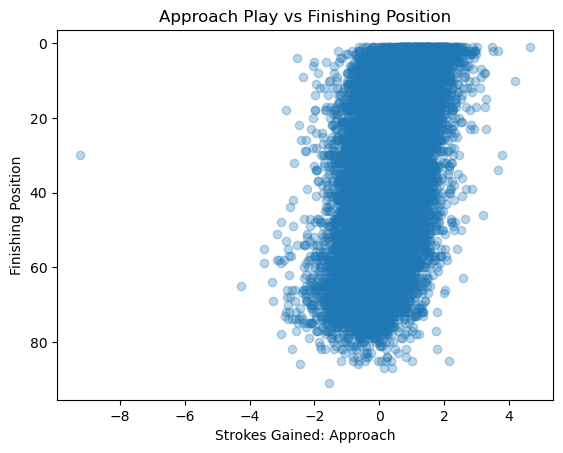

In [13]:
plt.scatter(eda_df["sg_app"], eda_df["pos"], alpha=0.3)
plt.xlabel("Strokes Gained: Approach")
plt.ylabel("Finishing Position")
plt.title("Approach Play vs Finishing Position")
plt.gca().invert_yaxis()
plt.show()

The scatter plot shows a downward trend: as strokes gained on approach increase, finishing position improves. This reinforces the correlation results.

In [14]:
top10_df = eda_df[eda_df["Top10"]]
non_top10_df = eda_df[~eda_df["Top10"]]

top10_means = top10_df[sg_cols].mean()
non_top10_means = non_top10_df[sg_cols].mean()

comparison = pd.DataFrame({
    "Top 10 Mean": top10_means,
    "Non-Top 10 Mean": non_top10_means
})

comparison

,Top 10 Mean,Non-Top 10 Mean
sg_putt,0.839960,0.121061
sg_arg,0.345992,0.064742
sg_app,0.886921,0.146420
sg_ott,0.470032,0.065949


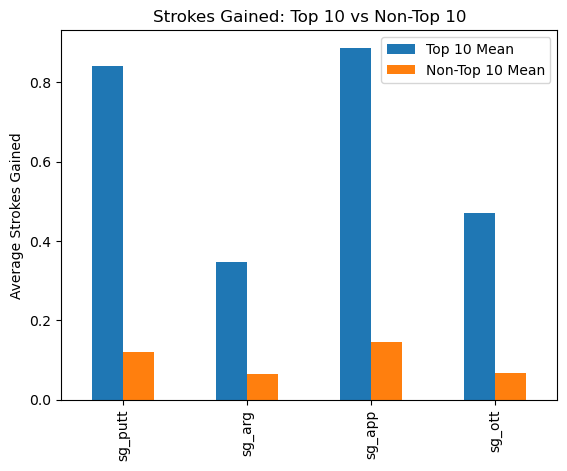

In [15]:
comparison.plot(kind="bar")
plt.ylabel("Average Strokes Gained")
plt.title("Strokes Gained: Top 10 vs Non-Top 10")
plt.show()

Players finishing in the Top 10 gained significantly more strokes in all categories compared to other players.  The largest difference appears in approach play, followed by putting.  These findings suggest that strong short game play is the most important factor in achieving high tournament finishes.

In [16]:
difference = top10_means - non_top10_means
difference.sort_values(ascending=False)

sg_app     0.740501
sg_putt    0.718899
sg_ott     0.404083
sg_arg     0.281250
dtype: float64

Top 10 players gained approximately .75 more strokes on approach per tournament than non-top 10 players.

### EDA Summary
Exploratory data analysis indicates that strokes gained on approach has the strongest relationship with improved finishing position.  Players who finish in the Top 10 gain significantly more strokes in all categories, particularly in approach play and putting.  These finding suggest that short-game performance is a key determining factor of high performance.

## Modeling Tournament Performance with Linear Regression
We will model finishing position as a function of strokes gained components.

In [17]:
from scipy.stats import linregress

res = linregress(eda_df["sg_app"], eda_df["pos"])

print("Slope (m):", res.slope)
print("R²:", res.rvalue**2)

Slope (m): -11.947280446391682
R²: 0.2261338705138331


A simple linear regression was fit to estimate the relationship between strokes gained on approach and finishing position.  The estimated slope was $m$ (-11.95), indicating that each additional stroke gained on approach improves finishing position by approximately $|m|$ (11.95) places on average.

The $R^2$ value of $0.23$ indicates that approach play alone explains approximately $23$% of the variation in finishing position.

In [18]:
for col in ["sg_app", "sg_putt", "sg_ott", "sg_arg"]:
    res = linregress(eda_df[col], eda_df["pos"])
    print(col, "Slope:", round(res.slope,2), "R²:", round(res.rvalue**2,3))

sg_app Slope: -11.95 R²: 0.226
sg_putt Slope: -10.79 R²: 0.188
sg_ott Slope: -12.79 R²: 0.133
sg_arg Slope: -11.05 R²: 0.085


Here we apply linear regression to putting, around-the-green play, approach play, and off-the-tee performance.  All four components showed negative slopes, which indicates higher strokes gained values are associated with better finishing positions.

Among the variables, strokes gained on approach produced the highest $R^2$ value (0.23), meaning it explains approximately 23% of the variation in finishing position on its own.

These results suggest that approach play is the most influential individual component in predicting tournament finish.

## Top 10 Probability as a Function of Strokes Gained

In [19]:
eda_df["app_bin"] = pd.qcut(eda_df["sg_app"], 4)

top10_rate = eda_df.groupby("app_bin",observed=True)["Top10"].mean()

top10_rate

app_bin
(-9.251, -0.27]    0.040662
(-0.27, 0.29]      0.098847
(0.29, 0.84]       0.184345
(0.84, 4.67]       0.362569
Name: Top10, dtype: float64

Players in the lowest quartile of approach performance have only a 4.1% probability of finishing in the Top 10.
In contrast, players in the highest quintile of approach performance have a 36.3% probability of finishing in the Top 10.

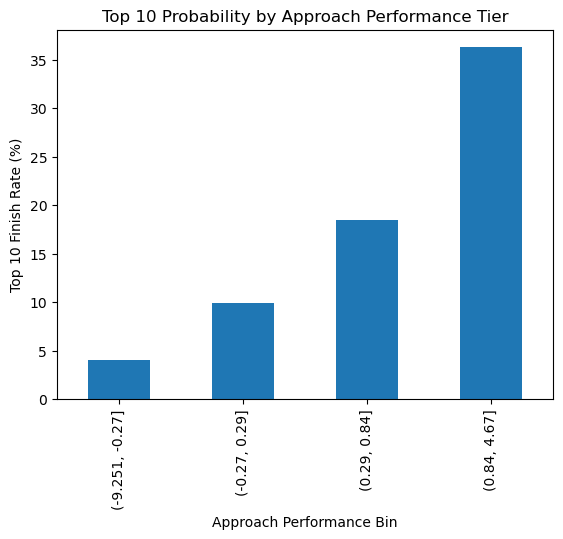

In [20]:
plt.figure()
(top10_rate * 100).plot(kind="bar")

plt.xlabel("Approach Performance Bin")
plt.ylabel("Top 10 Finish Rate (%)")
plt.title("Top 10 Probability by Approach Performance Tier")

plt.show()

### Top 10 Probability Conclusions
This analysis indicates that strong approach play increases the likelihood of a Top 10 finish by more than eight times compared to poor approach performance. These results suggest that iron play is a critical determinant of high-level tournament success.

## Conclusion
This project analyzed PGA Tour tournament-level data to identify which strokes gained components most influence finishing position and Top 10 outcomes. Both exploratory analysis and simple regression modeling showed that strokes gained on approach has the strongest relationship with tournament success. Improvements in approach play were associated with meaningful improvements in average finishing position, and players in the highest approach quintile were far more likely to record a Top 10 finish than those in the lowest quintile.

While putting, around-the-green play, and off-the-tee performance also contributed to results, their effects were smaller in magnitude. The models explain a meaningful portion of variation in tournament outcomes, though not all, indicating that additional factors also influence performance. Overall, this analysis demonstrates how quantitative modeling can translate performance metrics into clear, interpretable insights about competitive success in professional golf.